# Análise exploratória dos dados do ENEM 2023



## 1. Extração (Extract)

In [58]:
# carregamento dos dados
import pandas as pd

df_enem_2023_nac = pd.read_csv(
    'MICRODADOS_ENEM_2023.csv',
    sep=';',
    encoding='latin1'
)

df_nte = pd.read_csv(
    'tbl_nte_ba.csv',
    encoding='latin1'
)

# validação inicial da estrutura dos dados
display(df_enem_2023_nac.head(3))
display(df_nte.head(3))

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,210059085136,2023,14,M,2,1,1,1,17,1,...,C,C,B,B,A,B,B,A,A,B
1,210059527735,2023,12,M,2,1,0,1,16,1,...,B,A,B,B,A,A,C,A,D,B
2,210061103945,2023,6,F,1,1,1,1,0,1,...,B,A,A,B,A,A,A,A,A,B


,nome_nte,cod_municipio,nome_municipio,cod_territorio,nome_territorio,munic_regiao_ufob
0,NTE-01,2905305,CAFARNAUM,1,Irecê,0
1,NTE-01,2906204,CANARANA,1,Irecê,0
2,NTE-01,2913101,IBITITÁ,1,Irecê,0


## 2️ -  Tratamento (Transform)

### 2.1 – Seleção de variáveis (redução estrutural)

In [59]:
# remoção de variáveis fora do escopo analítico
df_enem_2023_nac = (
    df_enem_2023_nac.drop(
        columns=[
            'TP_FAIXA_ETARIA',
            'TP_ESTADO_CIVIL',
            'TP_NACIONALIDADE',
            'TP_ST_CONCLUSAO',
            'TP_ANO_CONCLUIU',
            'TP_ESCOLA',
            'TP_ENSINO',
            'IN_TREINEIRO',
            'CO_MUNICIPIO_ESC',
            'NO_MUNICIPIO_ESC',
            'CO_UF_ESC',
            'SG_UF_ESC',
            'TP_DEPENDENCIA_ADM_ESC',
            'TP_LOCALIZACAO_ESC',
            'TP_SIT_FUNC_ESC',
            'CO_UF_PROVA',
            'TP_PRESENCA_CN',
            'TP_PRESENCA_CH',
            'TP_PRESENCA_LC',
            'TP_PRESENCA_MT',
            'CO_PROVA_CN',
            'CO_PROVA_CH',
            'CO_PROVA_LC',
            'CO_PROVA_MT',
            'TX_RESPOSTAS_CN',
            'TX_RESPOSTAS_CH',
            'TX_RESPOSTAS_LC',
            'TX_RESPOSTAS_MT',
            'TP_LINGUA',
            'TX_GABARITO_CN',
            'TX_GABARITO_CH',
            'TX_GABARITO_LC',
            'TX_GABARITO_MT',
            'TP_STATUS_REDACAO',
            'NU_NOTA_COMP1',
            'NU_NOTA_COMP2',
            'NU_NOTA_COMP3',
            'NU_NOTA_COMP4',
            'NU_NOTA_COMP5',
            'Q001',
            'Q002',
            'Q003',
            'Q004',
            'Q005',
            'Q007',
            'Q008',
            'Q009',
            'Q010',
            'Q011',
            'Q012',
            'Q013',
            'Q014',
            'Q015',
            'Q016',
            'Q017',
            'Q018',
            'Q019',
            'Q020',
            'Q021',
            'Q022',
            'Q023',
            'Q024',
            'Q025',
        ]
    )
)

### 2.2 – Recorte territorial da base de dados

#### 2.2.1 – Filtragem territorial (Bahia)

In [60]:
# filtragem dos registros da Bahia
df_enem_ba_2023 = (
    df_enem_2023_nac[
        df_enem_2023_nac['SG_UF_PROVA'] == 'BA'
    ]
)

#### 2.2.2 – Vinculação aos Núcleos Territoriais de Educação (NTE)

In [61]:
# junção com tabela de referência territorial
df_enem_ba_2023 = df_enem_ba_2023.merge(
    df_nte[['cod_municipio', 'nome_nte']],
    left_on='CO_MUNICIPIO_PROVA',
    right_on='cod_municipio',
    how='left'
)

# remoção da chave auxiliar
df_enem_ba_2023 = df_enem_ba_2023.drop(columns=['cod_municipio'])

### 2.3 Construção de métricas derivadas

#### 2.3.1 Cálculo da média geral e média por NTE

A média individual penaliza ausências por refletir o critério real de concorrência no ENEM. Já as médias agregadas por NTE excluem médias nulas, pois o objetivo passa a ser avaliar o desempenho médio dos participantes efetivos, e não a taxa de comparecimento.

In [62]:
# dependências auxiliares
import numpy as np

# colunas de notas
col_notas = [
    'NU_NOTA_CN',
    'NU_NOTA_CH',
    'NU_NOTA_LC',
    'NU_NOTA_MT',
    'NU_NOTA_REDACAO',
]

# média geral por participante (apenas provas realizadas)
df_enem_ba_2023['NU_MEDIA_GERAL'] = (
    df_enem_ba_2023[col_notas]
    .mean(axis=1, skipna=True)
    .round(2)
)

# participantes totalmente ausentes → média inválida
df_enem_ba_2023.loc[
    df_enem_ba_2023[col_notas].isna().all(axis=1),
    'NU_MEDIA_GERAL'
] = np.nan

# média geral por NTE (apenas médias válidas)
df_enem_ba_2023['NU_MEDIA_GERAL_NTE'] = (
    df_enem_ba_2023
    .assign(
        NU_MEDIA_GERAL_VALIDO=lambda x: x['NU_MEDIA_GERAL'].where(
            x['NU_MEDIA_GERAL'] > 0
        )
    )
    .groupby('nome_nte')['NU_MEDIA_GERAL_VALIDO']
    .transform('mean')
    .round(2)
)

# validação inicial
display(df_enem_ba_2023.head(3))

,NU_INSCRICAO,NU_ANO,TP_SEXO,TP_COR_RACA,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,SG_UF_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q006,nome_nte,NU_MEDIA_GERAL,NU_MEDIA_GERAL_NTE
0,210058061539,2023,F,3,2913606,Ilhéus,BA,NaN,NaN,NaN,NaN,NaN,C,NTE-05,NaN,516.49
1,210059085137,2023,F,2,2927408,Salvador,BA,NaN,NaN,NaN,NaN,NaN,C,NTE-26,NaN,536.56
2,210059527729,2023,M,3,2910800,Feira de Santana,BA,NaN,NaN,NaN,NaN,NaN,B,NTE-19,NaN,522.67


#### 2.3.2 Classificação percentílica do desempenho individual (nível estadual)

In [63]:
# máscara de participantes efetivamente avaliados
mask_avaliados = df_enem_ba_2023['NU_MEDIA_GERAL'].notna()

# inicializar colunas
df_enem_ba_2023['PERCENTIL_MEDIA_GERAL'] = np.nan
df_enem_ba_2023['CATEGORIA_DESEMPENHO'] = 'Não avaliado'

# cálculo do percentil apenas para avaliados (arredondado em 2 casas)
df_enem_ba_2023.loc[mask_avaliados, 'PERCENTIL_MEDIA_GERAL'] = (
    df_enem_ba_2023
    .loc[mask_avaliados, 'NU_MEDIA_GERAL']
    .rank(pct=True)
    .mul(100)
    .round(2)
)

# definição das faixas percentílicas (exclui zero)
bins = [0, 20, 40, 60, 80, 100]
labels = ['Péssimo', 'Ruim', 'Regular', 'Bom', 'Ótimo']

# classificação apenas dos avaliados
df_enem_ba_2023.loc[mask_avaliados, 'CATEGORIA_DESEMPENHO'] = pd.cut(
    df_enem_ba_2023.loc[mask_avaliados, 'PERCENTIL_MEDIA_GERAL'],
    bins=bins,
    labels=labels,
    include_lowest=False,  # garante Péssimo > 0
    right=True
)

## 3 – Análise (Analysis)

### 3.1 – Análise da distribuição da média geral dos participantes

#### 3.1.1 Estatísticas descritivas – NU_MEDIA_GERAL

In [64]:
df_enem_ba_2023['NU_MEDIA_GERAL'].describe()

count    231727.000000
mean        521.426712
std          93.814544
min           0.000000
25%         458.860000
50%         518.160000
75%         583.760000
max         840.260000
Name: NU_MEDIA_GERAL, dtype: float64

#### 3.1.2 Distribuição da média geral e pontos de corte percentílicos

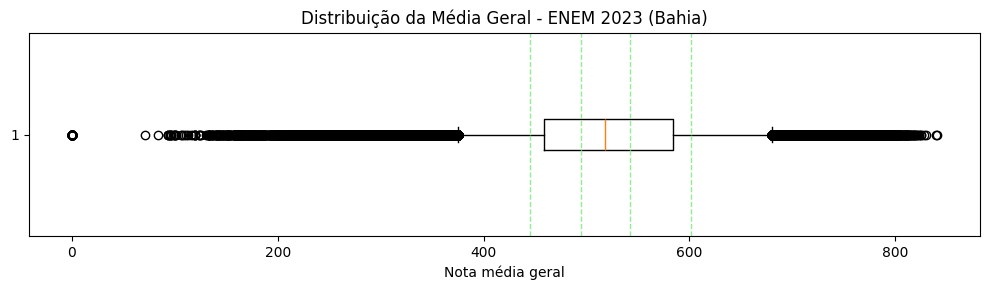

In [65]:
# dependências para gráficos
import matplotlib.pyplot as plt

valores = df_enem_ba_2023.loc[
    df_enem_ba_2023['NU_MEDIA_GERAL'].notna(),
    'NU_MEDIA_GERAL'
]

pontos = valores.quantile([0.2, 0.4, 0.6, 0.8])

plt.figure(figsize=(10, 3))

plt.boxplot(valores, vert=False, whis=(5, 95))

for x in pontos:
    plt.axvline(x, linestyle='--', linewidth=1, color='lightgreen')

plt.title('Distribuição da Média Geral - ENEM 2023 (Bahia)')
plt.xlabel('Nota média geral')

plt.tight_layout()
plt.show()

#### 3.1.3 Pontos de corte das categorias de desempenho (em valores de nota)

In [66]:
pontos_corte = (
    df_enem_ba_2023
        .loc[df_enem_ba_2023['NU_MEDIA_GERAL'].notna(), 'NU_MEDIA_GERAL']
        .quantile([0.2, 0.4, 0.6, 0.8, 1.0])
        .rename({
            0.2: 'Péssimo (≤ P20)',
            0.4: 'Ruim (> P20 e ≤ P40)',
            0.6: 'Regular (> P40 e ≤ P60)',
            0.8: 'Bom (> P60 e ≤ P80)',
            1.0: 'Ótimo (> P80)'
        })
        .round(2)
)

pontos_corte

Péssimo (≤ P20)            445.00
Ruim (> P20 e ≤ P40)       495.02
Regular (> P40 e ≤ P60)    542.02
Bom (> P60 e ≤ P80)        601.10
Ótimo (> P80)              840.26
Name: NU_MEDIA_GERAL, dtype: float64

### 3.2 – Contagem de participantes por NTE (tabela)

In [67]:
# Contagem de participantes com NU_MEDIA_GERAL não nula por NTE (ordem decrescente)
participantes_por_nte = (
    df_enem_ba_2023
    .loc[df_enem_ba_2023['NU_MEDIA_GERAL'].notna()]
    .groupby('nome_nte')
    .size()
    .sort_values(ascending=False)
)

participantes_por_nte

nome_nte
NTE-26        62539
NTE-19        18425
NTE-05        13430
NTE-20        13069
NTE-21        11630
NTE-13         9330
NTE-11         8159
NTE-10         7504
NTE-04         7245
NTE-18         7139
NTE-01         6155
NTE-07         5816
NTE-17         5699
NTE-09         5676
NTE-02         5658
NTE-22         5550
NTE-06         4828
NTE-03         4816
NTE-27         4658
NTE-25         4617
NTE-15         4090
NTE-16         3066
NTE-23         2894
NTE-14         2843
NTE-24         2609
NTE-08         2182
NTE-12         2100
dtype: int64

#### 3.2.1 – Contagem de participantes por NTE (gráfico)

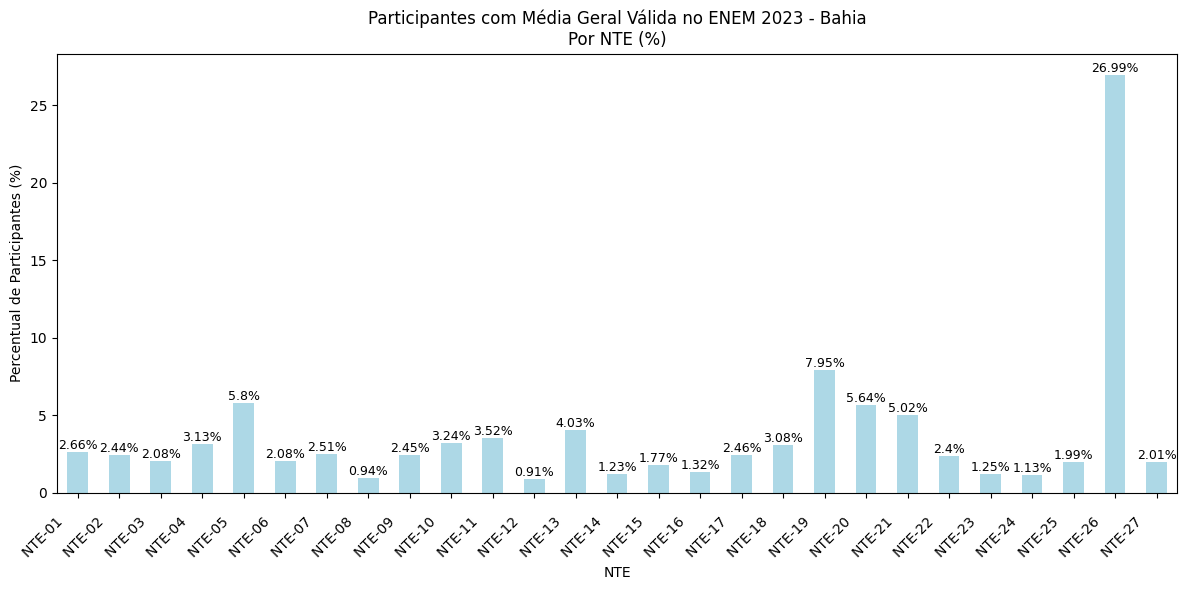

In [68]:

# total de participantes com média geral não nula
total = participantes_por_nte.sum()

# reindexar para ordem natural das NTEs
ordem_nte = sorted(participantes_por_nte.index, key=lambda x: int(x.split('-')[1]))
contagem_final = participantes_por_nte.reindex(ordem_nte)

# calcular porcentagem
percentual_final = (contagem_final / total * 100).round(2)

# gráfico de barras
ax = percentual_final.plot(kind='bar', figsize=(12, 6), color='lightblue')

plt.title('Participantes com Média Geral Válida no ENEM 2023 - Bahia\nPor NTE (%)')
plt.xlabel('NTE')
plt.ylabel('Percentual de Participantes (%)')
plt.xticks(rotation=45, ha='right')

# adicionar porcentagem sobre cada barra
for p, perc in zip(ax.patches, percentual_final):
    ax.annotate(
        f'{perc}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### 3.3 -  Desempenho médio no ENEM 2023 por NTE (visão geral)

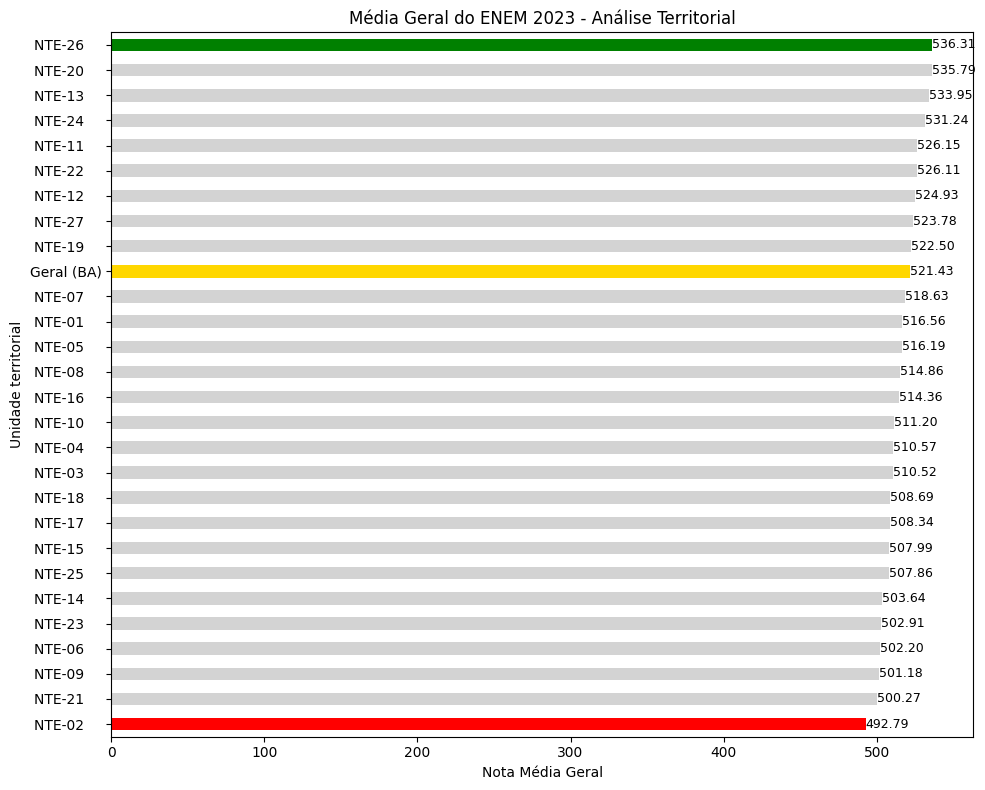

In [69]:

# média geral por NTE
media_por_nte = (
    df_enem_ba_2023
    .groupby('nome_nte')['NU_MEDIA_GERAL']
    .mean()
    .round(2)
)

# média geral da Bahia (média estadual)
media_bahia = (
    df_enem_ba_2023
    .loc[df_enem_ba_2023['NU_MEDIA_GERAL'].notna(), 'NU_MEDIA_GERAL']
    .mean()
    .round(2)
)

# série final com inclusão explícita da Bahia
media_final = media_por_nte.copy()
media_final['Geral (BA)'] = media_bahia

# ordenação crescente
media_final = media_final.sort_values(ascending=True)

# identificação dos extremos (ignorando a Bahia, se quiser)
valor_min = media_por_nte.min()
valor_max = media_por_nte.max()

# definição das cores
cores = []
for indice, valor in media_final.items():
    if indice == 'Geral (BA)':
        cores.append('gold')  # amarelo
    elif valor == valor_min:
        cores.append('red')
    elif valor == valor_max:
        cores.append('green')
    else:
        cores.append('lightgray')

# gráfico horizontal
ax = media_final.plot(
    kind='barh',
    figsize=(10, 8),
    color=cores
)

plt.title('Média Geral do ENEM 2023 - Análise Territorial')
plt.xlabel('Nota Média Geral')
plt.ylabel('Unidade territorial')

# rótulos de valor
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.2f}',
        (
            p.get_width(),
            p.get_y() + p.get_height() / 2
        ),
        va='center',
        ha='left',
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### 3.3.1 Identificação dos NTEs em situação crítica de desempenho (20% inferiores)
Os 20% inferiores dizem respeito à distribuição do desempenho médio **entre os NTEs**, e não à proporção de estudantes. Assim, cada NTE possui o mesmo peso na classificação, independentemente do número de participantes.

In [70]:
# identificação dos NTEs com menor desempenho (20% inferiores)
qtd_nte = int(len(media_por_nte) * 0.20)

nte_criticos = (
    media_por_nte
    .sort_values(ascending=True)
    .head(qtd_nte)
)

nte_criticos

nome_nte
NTE-02        492.79
NTE-21        500.27
NTE-09        501.18
NTE-06        502.20
NTE-23        502.91
Name: NU_MEDIA_GERAL, dtype: float64

**RESULTADO:**

A partir da identificação dos NTEs pertencentes ao grupo dos 20% inferiores de desempenho médio,
observa-se que o **NTE-02** apresenta a menor média geral entre todos os núcleos analisados.

Diante desse resultado, as análises subsequentes passam a concentrar-se no **NTE-02**,
por se tratar do caso mais crítico em termos de desempenho médio no ENEM 2023,
permitindo uma investigação mais aprofundada de suas características sociodemográficas
e educacionais.

### 3.4 – Distribuição de participantes por sexo (tabela)

In [71]:
# definição do recorte analítico do NTE-02
mask_nte02 = (
    df_enem_ba_2023['nome_nte']
    .str.strip()
    .eq('NTE-02')
)

# contagem de participantes por sexo no NTE-02
contagem_sexo_nte02 = df_enem_ba_2023[mask_nte02]['TP_SEXO'].value_counts()
print(contagem_sexo_nte02)

TP_SEXO
F    5075
M    2513
Name: count, dtype: int64


### 3.5 – Distribuição de participantes por sexo (gráfico)

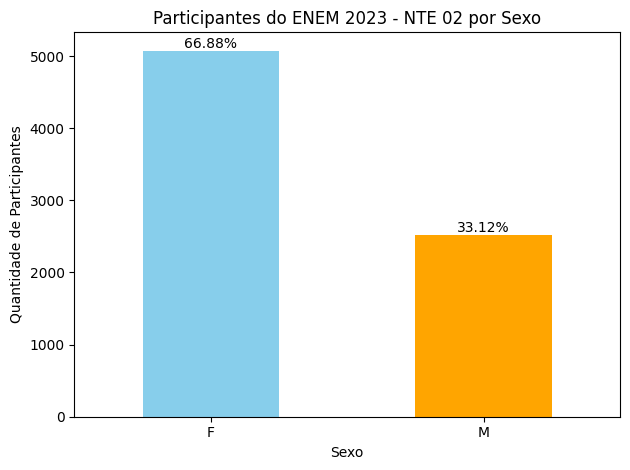

In [72]:


# contagem de participantes por sexo no NTE-02
contagem_sexo_nte02 = df_enem_ba_2023[mask_nte02]['TP_SEXO'].value_counts()

# total de participantes
total = contagem_sexo_nte02.sum()

# gráfico de barras
ax = contagem_sexo_nte02.plot(kind='bar', color=['skyblue', 'orange'])

plt.title('Participantes do ENEM 2023 - NTE 02 por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Quantidade de Participantes')
plt.xticks(rotation=0)

# adicionar apenas a porcentagem sobre cada barra
for p in ax.patches:
    altura = p.get_height()
    percentual = (altura / total) * 100
    ax.annotate(
        f'{percentual:.2f}%',
        (p.get_x() + p.get_width() / 2, altura),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### 3.6 – Distribuição de participantes por cor/raça (gráfico)

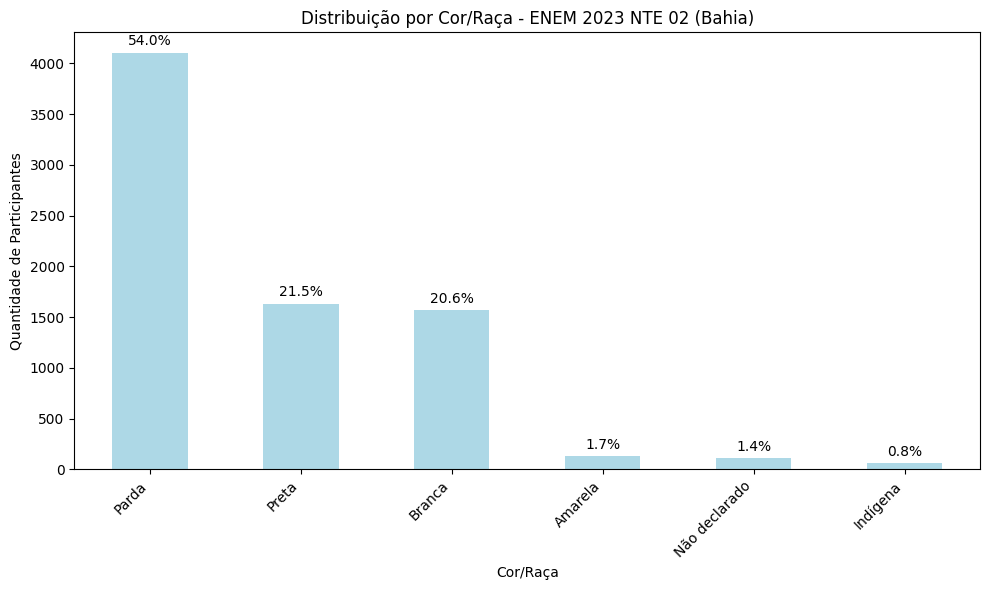

In [73]:
# mapa de códigos de cor/raça
cor_raca_map = {
    0: 'Não declarado',
    1: 'Branca',
    2: 'Preta',
    3: 'Parda',
    4: 'Amarela',
    5: 'Indígena',
    6: 'Não dispõe da informação'
}

# contagem de participantes por cor/raça no NTE-02
contagem_raca = (
    df_enem_ba_2023[mask_nte02]['TP_COR_RACA']
    .map(cor_raca_map)
    .value_counts()
)

# total de participantes
total = contagem_raca.sum()

# gráfico de barras
plt.figure(figsize=(10,6))
ax = contagem_raca.plot(kind='bar', color='lightblue')

# adicionar porcentagem sobre cada barra
for p in ax.patches:
    altura = p.get_height()
    percentual = (altura / total) * 100
    ax.annotate(
        f'{percentual:.1f}%',
        (p.get_x() + p.get_width() / 2, altura + total*0.01),
        ha='center'
    )

plt.title('Distribuição por Cor/Raça - ENEM 2023 NTE 02 (Bahia)')
plt.xlabel('Cor/Raça')
plt.ylabel('Quantidade de Participantes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.7 – Distribuição de participantes por faixa de renda familiar (gráfico)

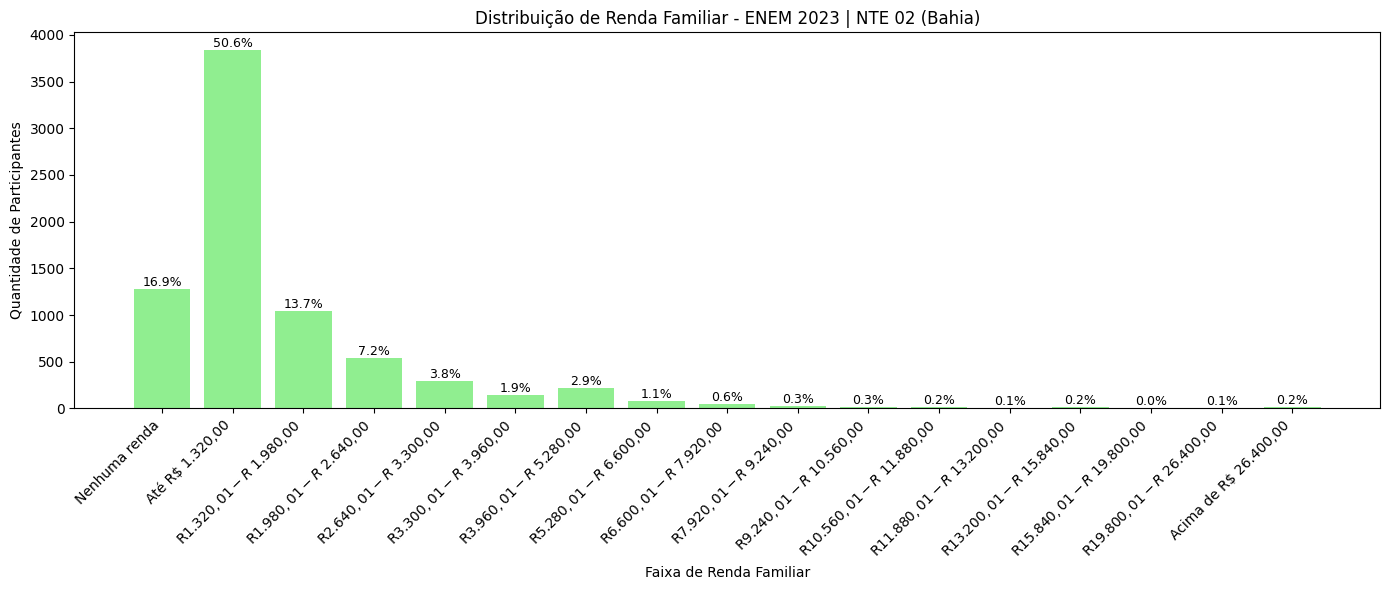

In [74]:
# Mapear códigos para rótulos de renda familiar
mapa_renda = {
    'A': 'Nenhuma renda',
    'B': 'Até R$ 1.320,00',
    'C': 'R$ 1.320,01 - R$ 1.980,00',
    'D': 'R$ 1.980,01 - R$ 2.640,00',
    'E': 'R$ 2.640,01 - R$ 3.300,00',
    'F': 'R$ 3.300,01 - R$ 3.960,00',
    'G': 'R$ 3.960,01 - R$ 5.280,00',
    'H': 'R$ 5.280,01 - R$ 6.600,00',
    'I': 'R$ 6.600,01 - R$ 7.920,00',
    'J': 'R$ 7.920,01 - R$ 9.240,00',
    'K': 'R$ 9.240,01 - R$ 10.560,00',
    'L': 'R$ 10.560,01 - R$ 11.880,00',
    'M': 'R$ 11.880,01 - R$ 13.200,00',
    'N': 'R$ 13.200,01 - R$ 15.840,00',
    'O': 'R$ 15.840,01 - R$ 19.800,00',
    'P': 'R$ 19.800,01 - R$ 26.400,00',
    'Q': 'Acima de R$ 26.400,00'
}

# Criar categoria ordenada
ordem_faixas = list(mapa_renda.values())
faixa_categ = pd.Categorical(
    df_enem_ba_2023[mask_nte02]['Q006'].map(mapa_renda),
    categories=ordem_faixas,
    ordered=True
)

# Contagem e percentual
contagem_renda = faixa_categ.value_counts().sort_index()
total = contagem_renda.sum()
percentual = (contagem_renda / total * 100).round(1)

# Gráfico de barras
fig, ax = plt.subplots(figsize=(14,6))
bars = ax.bar(contagem_renda.index, contagem_renda.values, color='lightgreen')

# Adicionar apenas percentual sobre cada barra
for bar, perc in zip(bars, percentual):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{perc}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Distribuição de Renda Familiar - ENEM 2023 | NTE 02 (Bahia)')
plt.xlabel('Faixa de Renda Familiar')
plt.ylabel('Quantidade de Participantes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4 – Exportação de resultados (Load)

In [75]:
caminho = r"C:/Users/Paulo/Desktop/CÓDIGOS/analise_educacao/enem-nte-bahia-analysis/data/etapa01"

# Salvar base analítica do ENEM Bahia 2023
df_enem_ba_2023.to_csv(
    f"{caminho}/enem_ba_2023_analysis_base.csv",
    index=False,
    encoding="utf-8-sig"
)
